In [152]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Optional

In [153]:
class Product_Review(TypedDict) :
    product_review: str
    is_spam: Optional[bool]
    sentiment_analysis: Optional[str]

In [154]:
from langgraph.graph import StateGraph
graph = StateGraph(Product_Review)

In [155]:
def check_spam_node(state: Product_Review) -> dict:
    review = state["product_review"]
    is_spam = True
    return {"is_spam":is_spam}

In [156]:
graph.add_node("check_spam", check_spam_node)

In [157]:
def check_sentiment_node(state: Product_Review) -> dict:
    review = state["product_review"]
    sentiment_analysis = 'positive'
    return {"sentiment_analysis":sentiment_analysis}

In [158]:
graph.add_node("check_sentiment", check_sentiment_node)

In [159]:
def route_after_spam_check(state: Product_Review) -> str:
    if state["is_spam"]:
        return "spam"
    else:
        return "not_spam"

In [160]:
graph.add_conditional_edges(
    "check_spam",
    route_after_spam_check,
    {
        "spam": END,
        "not_spam": "check_sentiment"
    }
)

In [161]:
graph.add_edge(START,"check_spam")
# graph.add_edge("check_spam","check_sentiment")
graph.add_edge("check_sentiment",END)

In [162]:
app = graph.compile()

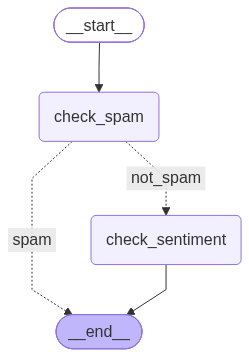

In [163]:
app

In [164]:
result = app.invoke({"product_review": "This is a great product, highly recommend!"})
print(result)

{'product_review': 'This is a great product, highly recommend!', 'is_spam': True}
